# Model 1a IMPROVED: FO permeate flux, longer-term run (replicate 1).

Upgrades over the baseline RandomForest (models/fo_flux_longterm_rf.joblib):
  1. Feature engineering: lag features, rolling means, and rate-of-change features
     exploit the fact this is an autocorrelated time series, not i.i.d. samples.
  2. TimeSeriesSplit cross-validation instead of random KFold: for a time series,
     random shuffling leaks future information into training folds and inflates
     the CV score. TimeSeriesSplit always trains on the past and tests on the future.
  3. Three model families compared head-to-head with the SAME features/CV:
     RandomForest (baseline), HistGradientBoostingRegressor, XGBoost.
  4. Light hyperparameter search (RandomizedSearchCV) for the boosting models.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
import joblib

In [2]:
df = pd.read_csv("data/fo_flux_longterm_rep1_full.csv").sort_values("time_min").reset_index(drop=True)

In [3]:
# ---- feature engineering -------------------------------------------------
for lag in (1, 3, 5):
    df[f"Jw_lag{lag}"] = df["Jw"].shift(lag)
for col in ("feed_cond_mScm", "draw_cond_mScm", "feed_temp_C", "draw_temp_C"):
    df[f"{col}_roll5"] = df[col].rolling(5, min_periods=1).mean()
df["draw_feed_cond_ratio"] = df["draw_cond_mScm"] / df["feed_cond_mScm"]
df["time_since_start"] = df["time_min"] - df["time_min"].min()
df = df.dropna().reset_index(drop=True)  # drop rows with NaN lag at the start

In [4]:
base_features = ["time_min", "feed_cond_mScm", "draw_cond_mScm", "feed_temp_C",
                  "draw_temp_C", "RO_TMP_bar", "FO_TMP_bar"]
new_features = ["Jw_lag1", "Jw_lag3", "Jw_lag5", "feed_cond_mScm_roll5",
                 "draw_cond_mScm_roll5", "feed_temp_C_roll5", "draw_temp_C_roll5",
                 "draw_feed_cond_ratio"]
features = base_features + new_features

In [5]:
X = df[features].values
y = df["Jw"].values
n = len(df)
split = int(n * 0.75)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
t_train, t_test = df["time_min"].values[:split], df["time_min"].values[split:]

In [6]:
tscv = TimeSeriesSplit(n_splits=5)

In [7]:
# ---- baseline (same as before, for a fair side-by-side) -------------------
rf_baseline = RandomForestRegressor(n_estimators=400, max_depth=8, min_samples_leaf=3, random_state=42)
rf_baseline.fit(X_train[:, :len(base_features)], y_train)
pred_rf_base = rf_baseline.predict(X_test[:, :len(base_features)])
r2_rf_base = r2_score(y_test, pred_rf_base)
cv_rf_base = cross_val_score(
    RandomForestRegressor(n_estimators=400, max_depth=8, min_samples_leaf=3, random_state=42),
    X[:, :len(base_features)], y, cv=tscv, scoring="r2",
)

In [8]:
# ---- candidate 1: RandomForest + engineered features -----------------------
rf_new = RandomForestRegressor(n_estimators=400, max_depth=8, min_samples_leaf=3, random_state=42)
rf_new.fit(X_train, y_train)
pred_rf_new = rf_new.predict(X_test)
r2_rf_new = r2_score(y_test, pred_rf_new)
cv_rf_new = cross_val_score(rf_new, X, y, cv=tscv, scoring="r2")

In [9]:
# ---- candidate 2: HistGradientBoostingRegressor, tuned ----------------------
hgb_param_dist = {
    "max_depth": [3, 5, 8, None],
    "learning_rate": [0.02, 0.05, 0.1, 0.2],
    "max_iter": [100, 200, 400],
    "min_samples_leaf": [5, 10, 20],
    "l2_regularization": [0.0, 0.1, 1.0],
}
hgb_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42), hgb_param_dist,
    n_iter=20, cv=tscv, scoring="r2", random_state=42, n_jobs=-1,
)
hgb_search.fit(X_train, y_train)
hgb_best = hgb_search.best_estimator_
pred_hgb = hgb_best.predict(X_test)
r2_hgb = r2_score(y_test, pred_hgb)
cv_hgb = cross_val_score(hgb_best, X, y, cv=tscv, scoring="r2")

In [10]:
# ---- candidate 3: XGBoost, tuned -------------------------------------------
xgb_param_dist = {
    "max_depth": [3, 4, 6, 8],
    "learning_rate": [0.02, 0.05, 0.1, 0.2],
    "n_estimators": [100, 200, 400],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0],
}
xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, objective="reg:squarederror"), xgb_param_dist,
    n_iter=20, cv=tscv, scoring="r2", random_state=42, n_jobs=-1,
)
xgb_search.fit(X_train, y_train)
xgb_best = xgb_search.best_estimator_
pred_xgb = xgb_best.predict(X_test)
r2_xgb = r2_score(y_test, pred_xgb)
cv_xgb = cross_val_score(xgb_best, X, y, cv=tscv, scoring="r2")

In [11]:
# ---- summary ----------------------------------------------------------------
summary = pd.DataFrame({
    "model": ["RandomForest (baseline features)", "RandomForest (+engineered features)",
              "HistGradientBoosting (tuned)", "XGBoost (tuned)"],
    "holdout_R2": [r2_rf_base, r2_rf_new, r2_hgb, r2_xgb],
    "TimeSeriesSplit_CV_R2_mean": [cv_rf_base.mean(), cv_rf_new.mean(), cv_hgb.mean(), cv_xgb.mean()],
    "TimeSeriesSplit_CV_R2_std": [cv_rf_base.std(), cv_rf_new.std(), cv_hgb.std(), cv_xgb.std()],
})
print(summary.to_string(index=False))

                              model  holdout_R2  TimeSeriesSplit_CV_R2_mean  TimeSeriesSplit_CV_R2_std
   RandomForest (baseline features)   -0.054464                   -3.575245                   5.966274
RandomForest (+engineered features)    0.566479                   -0.053849                   0.804580
       HistGradientBoosting (tuned)    0.376327                   -0.034948                   0.653248
                    XGBoost (tuned)    0.337917                   -0.346717                   1.005321


In [12]:
best_idx = summary["TimeSeriesSplit_CV_R2_mean"].idxmax()
best_name = summary.loc[best_idx, "model"]
best_model = [rf_baseline, rf_new, hgb_best, xgb_best][best_idx]
best_pred_test = [pred_rf_base, pred_rf_new, pred_hgb, pred_xgb][best_idx]
print(f"\nBest model by TimeSeriesSplit CV: {best_name}")


Best model by TimeSeriesSplit CV: HistGradientBoosting (tuned)


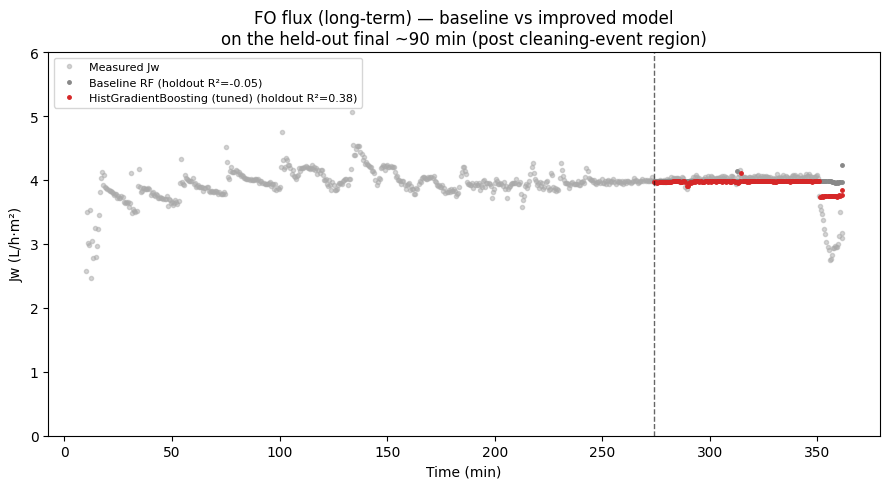

In [13]:
# ---- plot: baseline vs best model on the held-out region -------------------
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df["time_min"], y, "o", ms=3, color="#aaa", alpha=0.5, label="Measured Jw")
ax.plot(t_test, pred_rf_base, ".", ms=5, color="#888", label=f"Baseline RF (holdout R²={r2_rf_base:.2f})")
ax.plot(t_test, best_pred_test, ".", ms=5, color="#d62728", label=f"{best_name} (holdout R²={summary.loc[best_idx,'holdout_R2']:.2f})")
ax.axvline(t_test[0], color="k", linestyle="--", lw=1, alpha=0.6)
ax.set_xlabel("Time (min)"); ax.set_ylabel("Jw (L/h·m²)")
ax.set_title("FO flux (long-term) — baseline vs improved model\non the held-out final ~90 min (post cleaning-event region)")
ax.legend(fontsize=8)
ax.set_ylim(0, 6)
plt.tight_layout()
plt.savefig("plots/model1a_improved_comparison.png", dpi=150)
plt.show()

In [14]:
# feature importance from best tree model (if it exposes one)
if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)
    print("\nFeature importances (best model):\n", imp.head(10))

In [15]:
joblib.dump(best_model, "models/fo_flux_longterm_improved.joblib")
summary.to_csv("models/fo_flux_longterm_model_comparison.csv", index=False)
with open("models/metrics_fo_flux_longterm_improved.txt", "w") as f:
    f.write(summary.to_string(index=False))
    f.write(f"\n\nBest model: {best_name}\n")
    f.write(f"Best hyperparameters: {hgb_search.best_params_ if best_idx==2 else (xgb_search.best_params_ if best_idx==3 else 'n/a (default RF)')}\n")
    f.write("\nNote: 'holdout_R2' is the same strict chronological 75/25 split used in the baseline\n"
            "notebook (train on first ~4.5h, test on final ~90 min spanning a cleaning event) —\n"
            "genuinely hard to extrapolate into. TimeSeriesSplit_CV_R2 is a fairer, less biased\n"
            "estimate of typical generalization within the interior of the run.\n")
print("done")

done
